In [1]:
print("Hello, World!")

Hello, World!


In [2]:
from dotenv import load_dotenv
import os

load_dotenv()

True

In [3]:
from langchain_openai import ChatOpenAI

In [4]:
chat_llm = ChatOpenAI(model="gpt-4o-mini")

In [5]:
chat_llm.invoke("What is the capital of France?").content

'The capital of France is Paris.'

In [6]:
from typing_extensions import TypedDict, Annotated
import operator
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage

In [7]:
class GraphState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

In [8]:
def llm_call(state: GraphState) -> dict:
    response = chat_llm.invoke(state["messages"])
    return {"messages": state["messages"] + [response]}

In [9]:
def token_counter(state: GraphState) -> dict:
    """Count tokens (simple word count) in the last AI message."""
    last_msg = state["messages"][-1]
    text = last_msg.content
    token_number = len(text.split())
    summary = f"Total token number in the generated answer (word count) is {token_number}"
    return {
        "messages": [AIMessage(content=summary)]
    }

In [10]:
from langgraph.graph import StateGraph

In [11]:
builder = StateGraph(GraphState)

In [12]:
builder.add_node("llm_call", llm_call)
builder.add_node("token_counter", token_counter)


In [13]:
builder.set_entry_point("llm_call")
builder.add_edge("llm_call", "token_counter")
builder.set_finish_point("token_counter")

In [14]:
app = builder.compile()

In [15]:
app.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

In [16]:
from IPython.display import Image, display

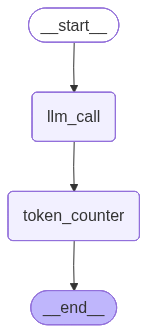

In [17]:
display(Image(app.get_graph().draw_mermaid_png()))

In [18]:
result = app.invoke({"messages": [HumanMessage(content="What is the capital of France?")]})
print(result["messages"][-1].content)

Total token number in the generated answer (word count) is 6


In [19]:
for m in result["messages"]:
    print(type(m).__name__, ":", m.content)

HumanMessage : What is the capital of France?
HumanMessage : What is the capital of France?
AIMessage : The capital of France is Paris.
AIMessage : Total token number in the generated answer (word count) is 6


In [20]:
chat_llm

ChatOpenAI(profile={'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x112ceb950>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x11388f7d0>, root_client=<openai.OpenAI object at 0x112db1a30>, root_async_client=<openai.AsyncOpenAI object at 0x113241160>, model_name='gpt-4o-mini', model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True)

In [21]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [22]:
api_wrapper = WikipediaAPIWrapper(top_k_results=5, doc_content_chars_max=500)

In [23]:
wiki_tool = WikipediaQueryRun(api_wrapper=api_wrapper)

In [24]:
wiki_tool.run({"query": "Generative AI"})

'Page: Generative artificial intelligence\nSummary: Generative artificial intelligence, also known as generative AI or GenAI, is a subfield of artificial intelligence that uses generative models to generate text, images, videos, audio, software code or other forms of data. These models learn the underlying patterns and structures of their training data, and use them to generate new data in response to input, which often takes the form of natural language prompts.\nThe prevalence of generative AI to'

'Page: Generative artificial intelligence\nSummary: Generative artificial intelligence, also known as generative AI or GenAI, is a subfield of artificial intelligence that uses generative models to generate text, images, videos, audio, software code or other forms of data. These models learn the underlying patterns and structures of their training data, and use them to generate new data in response to input, which often takes the form of natural language prompts.\nThe prevalence of generative AI to'

In [25]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults

TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

In [26]:
TAVILY_API_KEY

'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'

In [27]:
tool = TavilySearchResults(api_key=TAVILY_API_KEY)

/var/folders/ln/2r0y155n0hl7k61ty35cjdjc0000gn/T/ipykernel_68204/3716120651.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults(api_key=TAVILY_API_KEY)


In [28]:
tool.invoke({"query": "What is the latest news on Generative AI?"})

[{'title': 'Generative AI news and analysis - TechCrunch',
  'url': 'https://techcrunch.com/tag/generative-ai/',
  'content': 'Crunchboard\n\nContact Us\n\n# Generative AI\n\nTechCrunch covers the latest news and analysis in Generative AI (GenAI). Read the latest on startups and founders building artificial intelligence tools. From OpenAI with ChatGPT, to Google with Gemini—TechCrunch covers the entire ecosystem.\n\n### \n\nSpotify logo\n\n### Spotify says its best developers haven’t written a line of code since December, thanks to AI\n\nscene from House of David\n\n### Amazon to begin testing AI tools for film and TV production next month\n\nRoblox 4D\n\n### Roblox’s 4D creation feature is now available in open beta\n\nMozilla/Firefox logo\n\n### Firefox will soon let you block all of its generative AI features\n\n### Node-based design tool Flora raises $42M from Redpoint Ventures\n\nImage of a user prompting the new Slackbot interface. [...] Image of a user prompting the new Slackbot

In [29]:
from langchain_community.tools import DuckDuckGoSearchResults
search = DuckDuckGoSearchResults()

In [30]:
search.invoke("What is the latest news on iphone17")

Impersonate 'chrome_118' does not exist, using 'random'


"snippet: 1 week ago - iOS 17 is the seventeenth major release of Apple's iOS operating system for the iPhone. It is the direct successor to iOS 16. It was announced on June 5, 2023, at Apple's annual Worldwide Developers Conference alongside watchOS 10, iPadOS 17, tvOS 17 and macOS Sonoma., title: iOS 17 - Wikipedia, link: https://en.wikipedia.org/wiki/IOS_17, snippet: 3 days ago - Apple's sequel to the iPhone 16E may be getting several new features seen on the iPhone 17, but keep its $599 price., title: iPhone 17E Release Date, Price, and Specs - News & Rumors - CNET, link: https://www.cnet.com/tech/mobile/iphone-17e-release-date-price-specs-features-rumors/, snippet: 1 week ago - Last February was the first time Apple released an “e” series phone with the introduction of the iPhone 16e. While it’s difficult to predict the release date for the iPhone 17e, notorious Apple insider and Bloomberg columnist Mark Gurman claimed on 8 February in his PowerOn newsletter that its launch was “i

In [31]:
from langchain_community.tools import YouTubeSearchTool

In [32]:
tool = YouTubeSearchTool()

In [33]:
tool.name

'youtube_search'

In [34]:
tool.description

'search for youtube videos associated with a person. the input to this tool should be a comma separated list, the first part contains a person name and the second a number that is the maximum number of video results to return aka num_results. the second part is optional'

'search for youtube videos associated with a person. the input to this tool should be a comma separated list, the first part contains a person name and the second a number that is the maximum number of video results to return aka num_results. the second part is optional'

In [35]:
tool.run("Rajarshi Ray Guitar")

"['https://www.youtube.com/watch?v=RW28GYXzsRU&list=RDRW28GYXzsRU&start_radio=1&pp=ygUTUmFqYXJzaGkgUmF5IEd1aXRhcqAHAQ%3D%3D', 'https://www.youtube.com/watch?v=6CNrPurWwiI&list=RD6CNrPurWwiI&start_radio=1&pp=ygUTUmFqYXJzaGkgUmF5IEd1aXRhcqAHAQ%3D%3D']"

In [36]:
def multiply(a: int, b: int) -> int:
    return a * b

In [37]:
multiply(3, 4)

12

In [38]:
from langchain.tools import tool
@tool
def multiply(a: int, b: int) -> int:
    """Multiplies two numbers."""
    return a * b

In [39]:
multiply.invoke({"a": 3, "b": 4})

12

In [40]:
@tool
def get_word_length(word: str) -> int:
    """Returns the length of the given word."""
    return len(word)

In [41]:
get_word_length.invoke("Generative AI")

13

In [42]:
import yfinance as yf

In [43]:
@tool
def get_stock_price(ticker:str) -> str: 
    """this is a tool to get stock price using yfinance"""
    try:
        stock = yf.Ticker(ticker)

        # Get last 1 day historical data
        data = stock.history(period="1d")

        if data.empty:
            return f"No data found for ticker '{ticker}'. Please check the symbol."

        latest_close = data["Close"].iloc[-1]

        # Detect currency
        currency = stock.info.get("currency", "")
        symbol_map = {
            "INR": "₹",
            "USD": "$",
            "EUR": "€",
            "GBP": "£"
        }

        symbol = symbol_map.get(currency, "")
        currency_text = currency if currency else ""

        if symbol:
            return f"The last closing price of {ticker.upper()} was {symbol}{latest_close:.2f}."
        else:
            return f"The last closing price of {ticker.upper()} was {latest_close:.2f} {currency_text}."

    except Exception as e:
        return f"An error occurred while fetching stock data: {str(e)}"

In [44]:
get_stock_price.invoke({"ticker": "AAPL"})

'The last closing price of AAPL was $266.18.'

In [45]:
get_stock_price.invoke({"ticker": "TSLA"})

'The last closing price of TSLA was $399.83.'

In [53]:
tools = [get_stock_price, get_word_length, multiply, wiki_tool]

In [54]:
llm_with_tools=chat_llm.bind_tools(tools)

In [50]:
result = llm_with_tools.invoke("What is the length of the word 'Agentic'? Also, what is 5 multiplied by 7? And what's the latest stock price of AAPL?")

In [52]:
result.tool_calls

[{'name': 'get_word_length',
  'args': {'word': 'Agentic'},
  'id': 'call_CBDFTfsdQ0c2Jm542IhaFqDM',
  'type': 'tool_call'},
 {'name': 'multiply',
  'args': {'a': 5, 'b': 7},
  'id': 'call_HKyPyW2UbdFOK2vHdNzrX1HO',
  'type': 'tool_call'},
 {'name': 'get_stock_price',
  'args': {'ticker': 'AAPL'},
  'id': 'call_6ju1neYXTFlq7LxqiUQDPB0z',
  'type': 'tool_call'}]

In [57]:
result=llm_with_tools.invoke("What is the indian union budget details for 2026?")

In [58]:
result.tool_calls

[{'name': 'wikipedia',
  'args': {'query': 'Indian Union Budget 2026'},
  'id': 'call_Xuo2Q0JGwphFkRlLbl0j4YXU',
  'type': 'tool_call'}]

In [66]:
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import MessagesState, StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


In [67]:
def function1(state: MessagesState) -> MessagesState:
    pass

In [68]:
function_2=ToolNode(tools)

In [69]:
workflow=StateGraph(MessagesState)

In [70]:
workflow.add_node("llm", function1)
workflow.add_node("tools", function_2)

In [71]:
workflow.add_edge(START, "llm")

In [72]:
workflow.add_conditional_edges("llm", tools_condition)

In [73]:
workflow.add_edge("tools", "llm")


In [74]:
apps = workflow.compile()

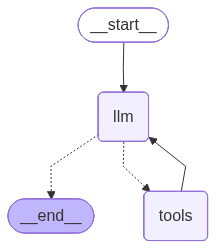

In [76]:
from IPython.display import Image, display
display(Image(apps.get_graph(xray=True).draw_mermaid_png()))